In [31]:
import pandas as pd
data = pd.read_csv("titanic.csv")
(data.isna().sum() / len(data) * 100).round(2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare           11.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [32]:
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Fare'] = data['Fare'].fillna(data['Fare'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Cabin'] = data['Cabin'].fillna('Unknown')
(data.isna().sum() / len(data) * 100).round(2)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Cabin          0.0
Embarked       0.0
dtype: float64

In [33]:

data['FamilySize'] = data['SibSp'] + data['Parch'] 
data['CabinType'] = data['Cabin'].str[0]

data = data.drop(columns = ['Name', 'Ticket'])

In [34]:
data = data.drop(columns = ['Cabin'])

data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['Embarked', 'CabinType'])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   FamilySize   891 non-null    int64  
 9   Embarked_C   891 non-null    bool   
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
 12  CabinType_A  891 non-null    bool   
 13  CabinType_B  891 non-null    bool   
 14  CabinType_C  891 non-null    bool   
 15  CabinType_D  891 non-null    bool   
 16  CabinType_E  891 non-null    bool   
 17  CabinType_F  891 non-null    bool   
 18  CabinType_G  891 non-null    bool   
 19  CabinType_T  891 no

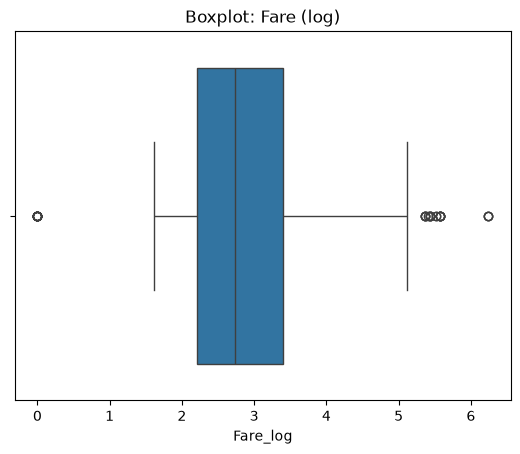

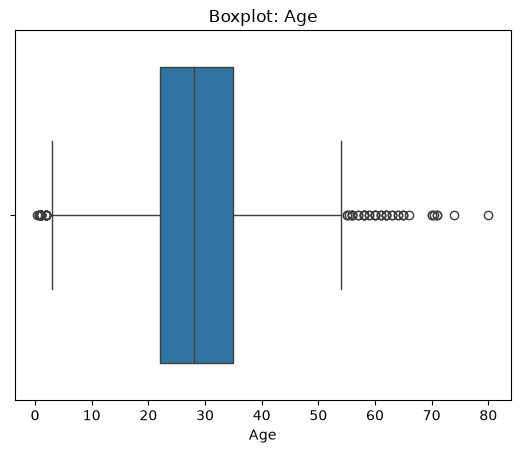

In [35]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

data['Fare_log'] = np.log1p(data['Fare'])

sns.boxplot(x=data['Fare_log'])
plt.title('Boxplot: Fare (log)')
plt.show()

sns.boxplot(x=data['Age'])
plt.title('Boxplot: Age')
plt.show()

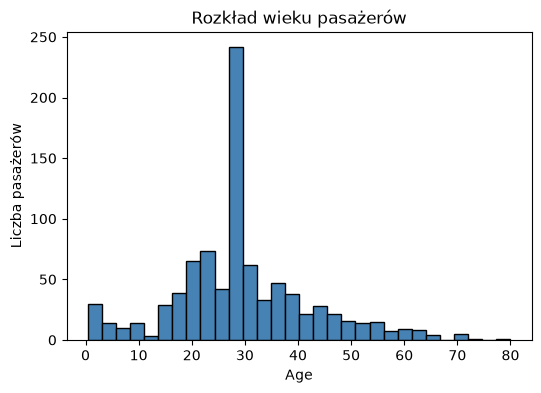

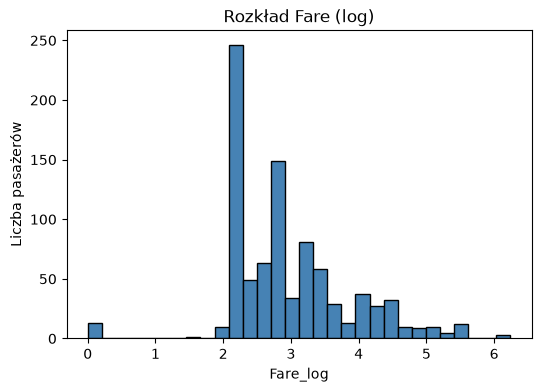

In [36]:
#rysowanie wykresu dla wieku
plt.figure(figsize=(6,4))
plt.hist(data['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Rozkład wieku pasażerów')
plt.xlabel('Age')
plt.ylabel('Liczba pasażerów')
plt.show()
#jest bardzo dużo w wieku 28 bo dla osób o których nie mielismy danych to zapisaliśmy medianę stąd taki wysoki słupek


#rysowanie wykresu dla opłaty za rejs
plt.figure(figsize=(6,4))
plt.hist(data['Fare_log'], bins=30, color='steelblue', edgecolor='black')
plt.title('Rozkład Fare (log)')
plt.xlabel('Fare_log')
plt.ylabel('Liczba pasażerów')
plt.show()

# użyliśmy skali logarytmicznej która lepiej zobrazowała rozkład ceny biletów

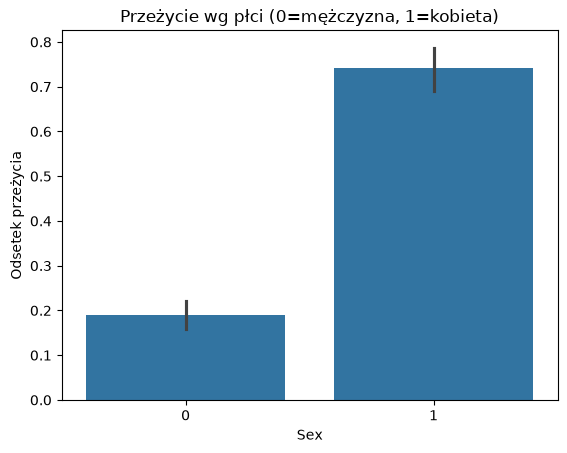

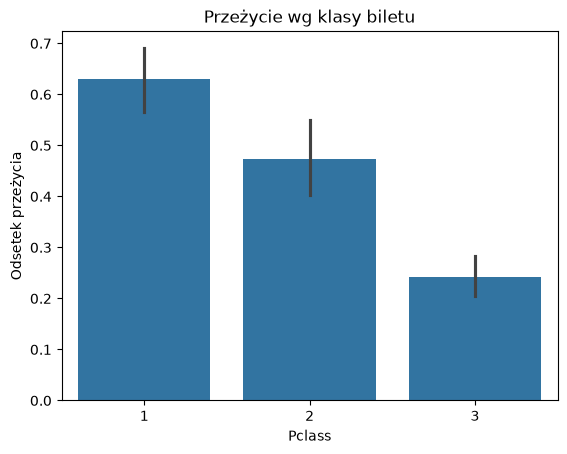

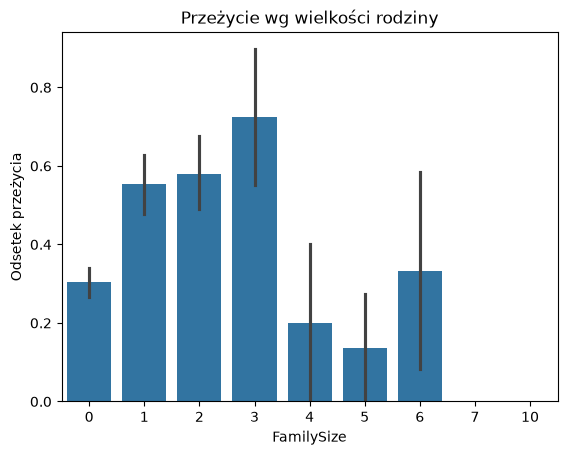

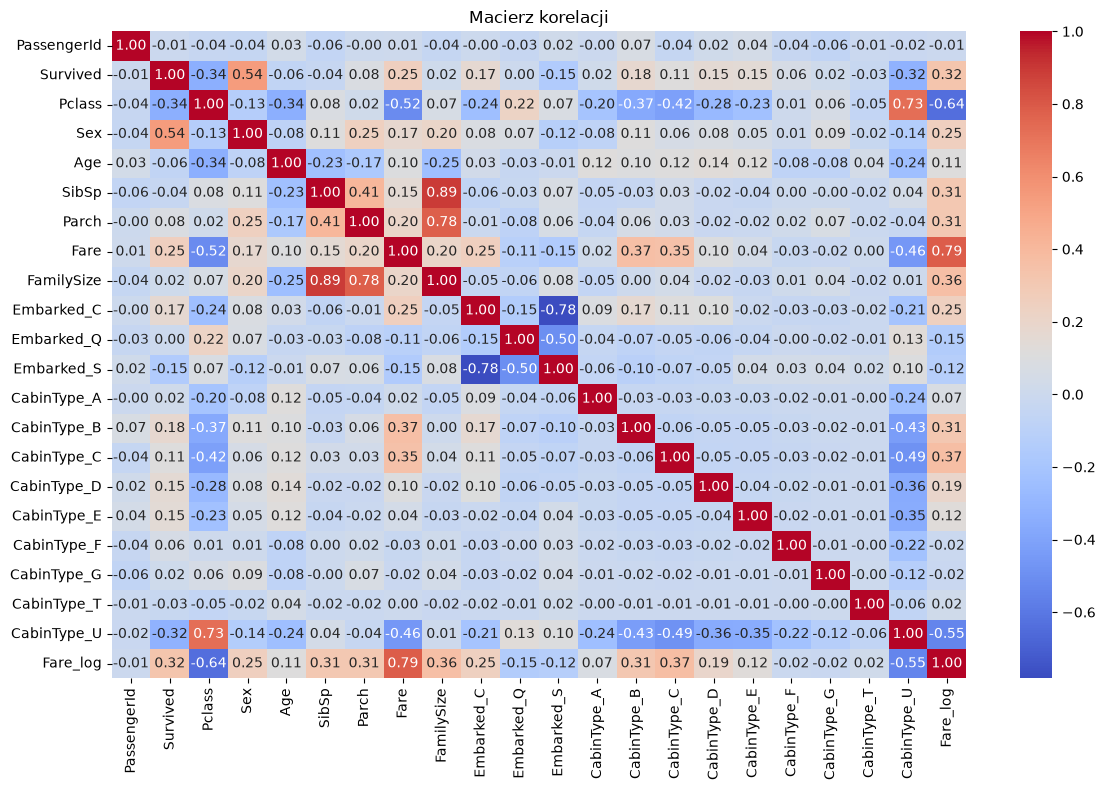

In [37]:
#rozkłady przeżycia w zależnosci od cech


#zależnie od płci
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Przeżycie wg płci (0=mężczyzna, 1=kobieta)')
plt.xlabel('Sex')
plt.ylabel('Odsetek przeżycia')
plt.show()


#zależnie od klasy biletu
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Przeżycie wg klasy biletu')
plt.xlabel('Pclass')
plt.ylabel('Odsetek przeżycia')
plt.show()


#podróżowanie z rodziną 
sns.barplot(x='FamilySize', y='Survived', data=data)
plt.title('Przeżycie wg wielkości rodziny')
plt.xlabel('FamilySize')
plt.ylabel('Odsetek przeżycia')
plt.show()


#heatmapa korelacji
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()